# Random Forest


In [1]:
# pip install pandas scikit-learn matplotlib seaborn
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110

In [2]:
df = pd.read_csv('cleaned_yrbs_data.csv')

TARGET = 'grade' if 'grade' in df.columns else df.columns[-1]
print(f"Detected target column: '{TARGET}'")
print(f"Shape: {df.shape}")
df.head()

Detected target column: 'grade'
Shape: (15694, 35)


,age,gender,education_level,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
0,15.0,Male,9th grade,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0
1,16.0,Male,11th grade,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
2,17.0,Female,10th grade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
3,14.0,Male,9th grade,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,0.0
4,16.0,Male,9th grade,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,2.0,3.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,0.0


Class counts:
grade
0.0     506
1.0     842
2.0    2667
3.0    5094
4.0    6585

Class proportions:
grade
0.0    0.032
1.0    0.054
2.0    0.170
3.0    0.325
4.0    0.420

Imbalance ratio (max/min): 13.01x
Imbalanced.


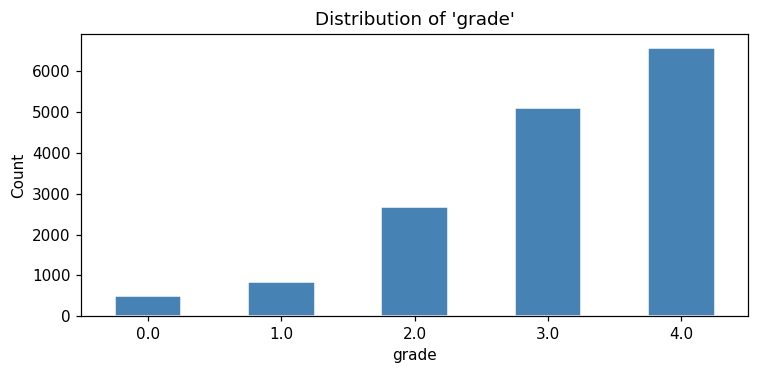

In [3]:
class_counts = df[TARGET].value_counts().sort_index()
class_ratio = (class_counts / class_counts.sum()).round(3)
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class counts:")
print(class_counts.to_string())
print("\nClass proportions:")
print(class_ratio.to_string())
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")
print("Imbalanced." if imbalance_ratio >= 2 else "Roughly balanced.")

fig, ax = plt.subplots(figsize=(7, 3.5))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f"Distribution of '{TARGET}'")
ax.set_xlabel(TARGET); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

In [4]:
df_model = df.copy()

# Missing values
n_missing = df_model.isnull().sum().sum()
if n_missing:
    for col in df_model.columns:
        if df_model[col].dtype.kind in 'biufc':
            df_model[col] = df_model[col].fillna(df_model[col].median())
        else:
            df_model[col] = df_model[col].fillna(df_model[col].mode().iloc[0])
print(f"Missing values handled: {n_missing}")

# Encode target
target_encoder = LabelEncoder()
df_model[TARGET] = target_encoder.fit_transform(df_model[TARGET].astype(str))

# Encode remaining categoricals
for col in df_model.select_dtypes(exclude='number').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
print(f"Features: {X.shape[1]}  |  Classes: {list(target_encoder.classes_)}")

Missing values handled: 0
Features: 34  |  Classes: ['0.0', '1.0', '2.0', '3.0', '4.0']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 12,555   Test: 3,139


In [6]:
# Baseline Random Forest
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
baseline_pred = rf_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"Baseline RF accuracy: {baseline_acc:.4f}")

Baseline RF accuracy: 0.4135


In [ ]:
# RandomizedSearchCV
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print("\nBest params:", rf_search.best_params_)
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV accuracy: 0.4373


Tuned RF  accuracy : 0.4304
Baseline  accuracy : 0.4135
Improvement        : +1.69 pp

              precision    recall  f1-score   support

         0.0       0.46      0.06      0.11       101
         1.0       0.00      0.00      0.00       168
         2.0       0.33      0.12      0.17       534
         3.0       0.34      0.36      0.35      1019
         4.0       0.49      0.69      0.58      1317

    accuracy                           0.43      3139
   macro avg       0.33      0.25      0.24      3139
weighted avg       0.39      0.43      0.39      3139



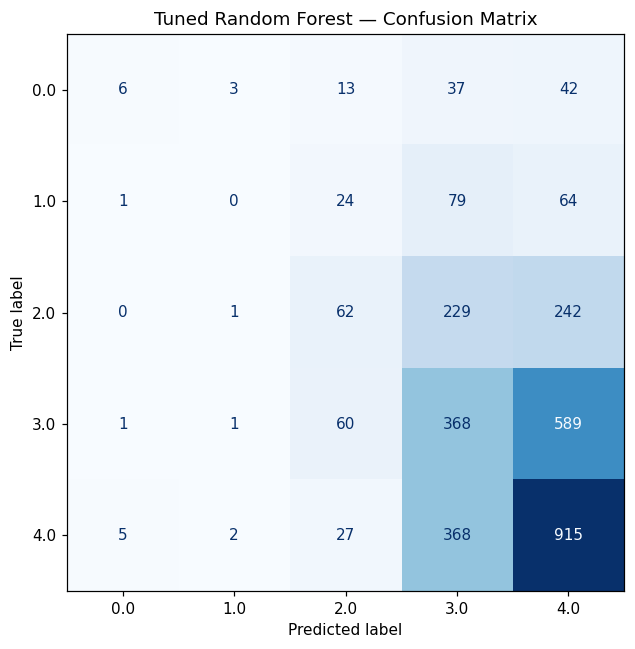

In [8]:
rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

print(f"Tuned RF  accuracy : {rf_acc:.4f}")
print(f"Baseline  accuracy : {baseline_acc:.4f}")
print(f"Improvement        : {(rf_acc - baseline_acc) * 100:+.2f} pp\n")
print(classification_report(
    y_test, rf_pred,
    target_names=target_encoder.classes_.astype(str),
    zero_division=0,
))

cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_.astype(str),
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Tuned Random Forest — Confusion Matrix')
plt.tight_layout(); plt.show()

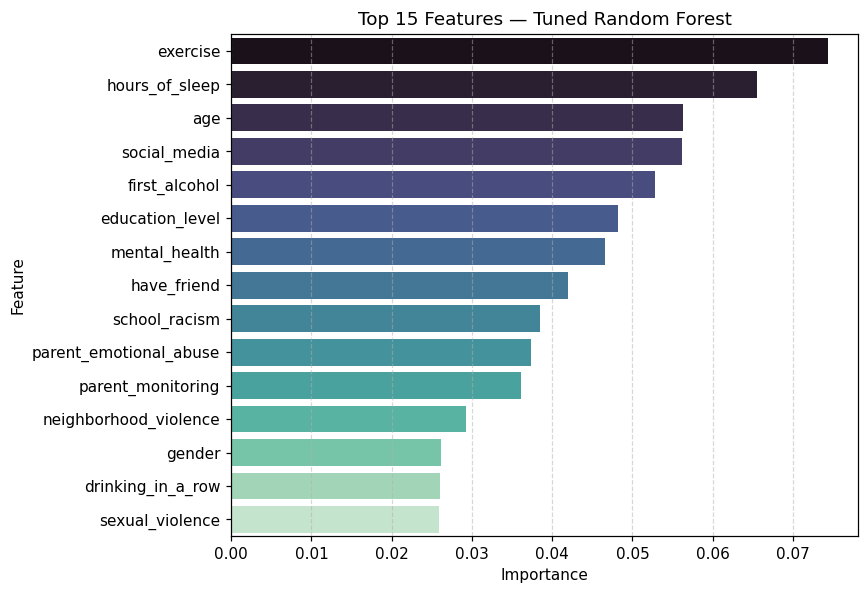

               Feature  Importance
              exercise    0.074382
        hours_of_sleep    0.065456
                   age    0.056325
          social_media    0.056168
         first_alcohol    0.052772
       education_level    0.048222
         mental_health    0.046517
           have_friend    0.041927
         school_racism    0.038480
parent_emotional_abuse    0.037323
     parent_monitoring    0.036173
 neighborhood_violence    0.029320
                gender    0.026122
     drinking_in_a_row    0.025995
       sexual_violence    0.025880


In [9]:
imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_best.feature_importances_,
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='mako', ax=ax)
ax.set_title('Top 15 Features — Tuned Random Forest')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

In [11]:
results = pd.DataFrame([
    {'Model': 'Random Forest (default)',
     'Accuracy':  baseline_acc,
     'Precision': precision_score(y_test, baseline_pred, average='weighted', zero_division=0),
     'Recall':    recall_score(y_test, baseline_pred, average='weighted', zero_division=0),
     'F1':        f1_score(y_test, baseline_pred, average='weighted', zero_division=0)},
    {'Model': 'Random Forest (tuned)',
     'Accuracy':  rf_acc,
     'Precision': rf_prec,
     'Recall': rf_rec,
     'F1': rf_f1},
]).round(4).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

best_model = results.iloc[0]['Model']
best_acc = results.iloc[0]['Accuracy']

print(f"\nBest model: {best_model} (accuracy = {best_acc:.4f})")

                  Model  Accuracy  Precision  Recall     F1
  Random Forest (tuned)    0.4304     0.3894  0.4304 0.3887
Random Forest (default)    0.4135     0.3817  0.4135 0.3787

Best model: Random Forest (tuned) (accuracy = 0.4304)
